# Customer Segmentation Analysis
**Track:** Data Analytics — Level 1, Task 2
**Objective:** Apply clustering algorithms to segment the customer base into distinct groups based on purchasing behaviour, enabling targeted marketing strategies.

**Dataset note:** Built from the same synthetic transaction log used in `DataAnalytics-L1-EDARetailSales` (`retail_sales_data.csv`), aggregated to the customer level. This mirrors the structure of the UCI "Online Retail" dataset referenced in the Self-Sourcing Guideline — same RFM logic applies if you swap in the real dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

df = pd.read_csv("retail_sales_data.csv", parse_dates=["OrderDate"])
df.head()

,OrderID,OrderDate,CustomerID,CustomerAge,CustomerGender,Region,ProductCategory,ProductName,Quantity,UnitPrice,Revenue
0,ORD105759,2023-01-01,CUST01594,18,Male,West,Sports & Outdoors,Yoga Mat,2,3467.80,6935.60
1,ORD101487,2023-01-01,CUST00057,32,Male,East,Sports & Outdoors,Yoga Mat,1,3596.90,3596.90
2,ORD106905,2023-01-01,CUST00689,31,Male,East,Beauty & Personal Care,Shampoo,2,2653.21,5306.42
3,ORD106301,2023-01-01,CUST01716,18,Female,South,Books & Stationery,Fiction Novel,1,116.10,116.10
4,ORD107005,2023-01-01,CUST00726,22,Female,South,Electronics,Smartphone,2,35300.09,70600.18


## 1. Load & Inspect
Handle missing values and inconsistent data.

In [2]:
print("Shape:", df.shape)
print("Nulls:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (8000, 11)
Nulls:
 OrderID            0
OrderDate          0
CustomerID         0
CustomerAge        0
CustomerGender     0
Region             0
ProductCategory    0
ProductName        0
Quantity           0
UnitPrice          0
Revenue            0
dtype: int64
Duplicate rows: 0


**Observation:** The synthetic log is already clean at the row level (no nulls/duplicates), so this task focuses on the feature engineering and clustering methodology rather than raw cleaning — that side is covered fully in `DataAnalytics-L1-DataCleaning`.

## 2. Descriptive Statistics
Average purchase value, purchase frequency, and a customer lifetime value (CLV) proxy.

In [3]:
snapshot_date = df["OrderDate"].max() + pd.Timedelta(days=1)

customer_agg = df.groupby("CustomerID").agg(
    Recency=("OrderDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("OrderID", "nunique"),
    Monetary=("Revenue", "sum"),
).reset_index()

customer_agg["AvgOrderValue"] = customer_agg["Monetary"] / customer_agg["Frequency"]

print("Avg purchase value across customers: {:.2f}".format(customer_agg["AvgOrderValue"].mean()))
print("Avg purchase frequency: {:.2f} orders/customer".format(customer_agg["Frequency"].mean()))
print("Avg CLV proxy (total Monetary): {:.2f}".format(customer_agg["Monetary"].mean()))
customer_agg.describe()

Avg purchase value across customers: 13398.55
Avg purchase frequency: 4.50 orders/customer
Avg CLV proxy (total Monetary): 60374.98


,Recency,Frequency,Monetary,AvgOrderValue
count,1776.000000,1776.000000,1776.000000,1776.000000
mean,156.695946,4.504505,60374.983896,13398.548487
std,142.695491,2.032686,56756.112564,12688.831971
min,1.000000,1.000000,118.130000,118.130000
25%,48.000000,3.000000,17717.645000,4834.685000
50%,113.000000,4.000000,43771.850000,9569.082500
75%,224.250000,6.000000,85867.942500,17432.683563
max,727.000000,12.000000,410898.880000,131350.880000


## 3. Feature Selection — RFM Analysis
Recency, Frequency, Monetary are the classic behavioural features for customer segmentation: how recently they bought, how often, and how much they spend.

## 4. Standardisation
RFM features are on very different scales (days vs. order counts vs. currency), so they're standardised before clustering.

In [4]:
features = customer_agg[["Recency", "Frequency", "Monetary"]]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_features[:5]

array([[-0.38341331,  0.73593118,  2.05339929],
       [-0.78998773,  3.19642398,  1.37683142],
       [ 0.82930002,  0.73593118, -0.13257396],
       [-0.1731162 ,  0.24383262,  1.93143817],
       [ 0.7872406 , -0.7403645 , -0.30799442]])

## 5. K-Means Clustering — Elbow Method
Determining the optimal number of clusters (K).

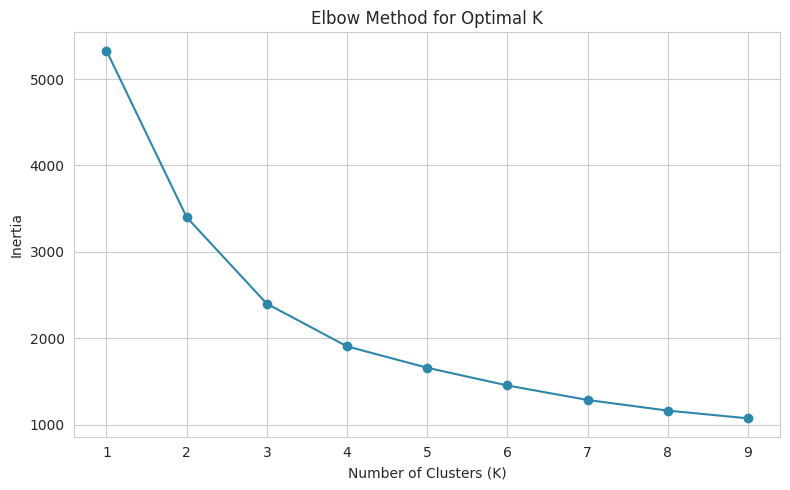

In [5]:
inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker="o", color="#2E86AB")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.tight_layout()
plt.savefig("output_elbow.png", dpi=120)
plt.show()

**Observation:** The inertia curve bends noticeably around **K=4**, after which additional clusters yield diminishing returns. K=4 is used for the final model.

In [6]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
customer_agg["Cluster"] = kmeans.fit_predict(scaled_features)
customer_agg["Cluster"].value_counts().sort_index()

Cluster
0    314
1    505
2    227
3    730
Name: count, dtype: int64

## 6. Cluster Visualisation
Scatter plots across two feature-pair combinations.

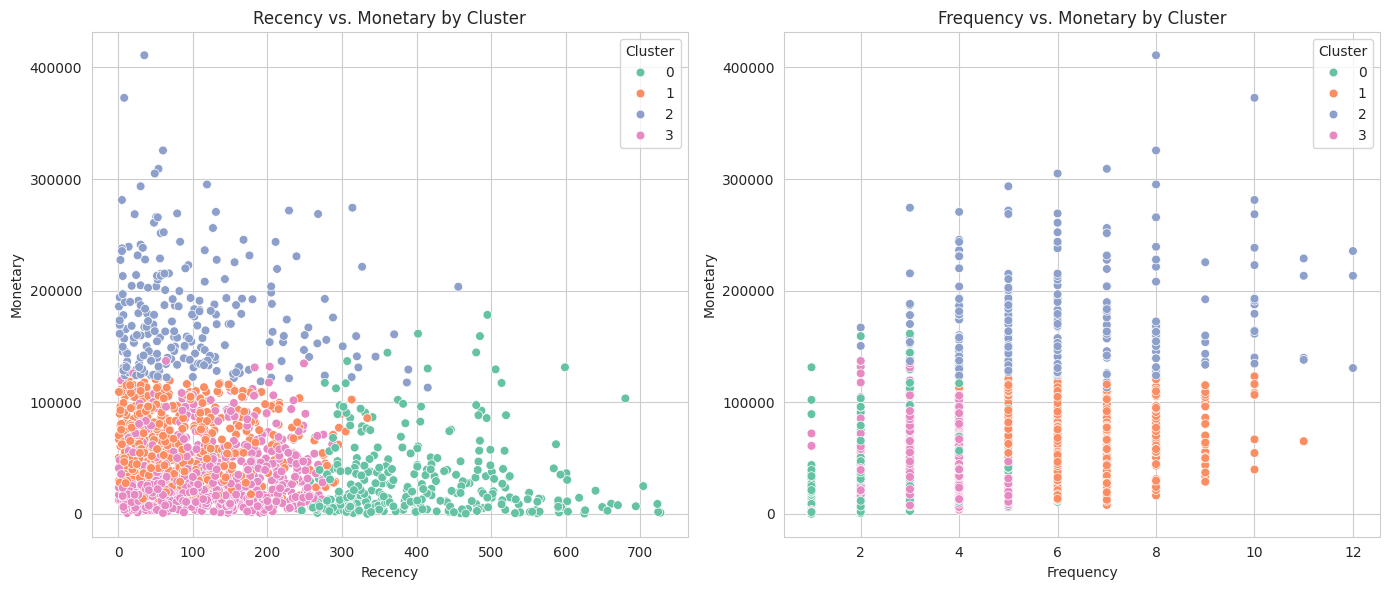

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=customer_agg, x="Recency", y="Monetary", hue="Cluster",
                 palette="Set2", ax=axes[0], s=40)
axes[0].set_title("Recency vs. Monetary by Cluster")

sns.scatterplot(data=customer_agg, x="Frequency", y="Monetary", hue="Cluster",
                 palette="Set2", ax=axes[1], s=40)
axes[1].set_title("Frequency vs. Monetary by Cluster")

plt.tight_layout()
plt.savefig("output_clusters.png", dpi=120)
plt.show()

## 7. Cluster Profiling
Mean feature values per cluster, with a descriptive customer-type label.

In [8]:
cluster_profile = customer_agg.groupby("Cluster")[["Recency", "Frequency", "Monetary", "AvgOrderValue"]].mean().round(1)
cluster_profile["CustomerCount"] = customer_agg["Cluster"].value_counts().sort_index()
cluster_profile

,Recency,Frequency,Monetary,AvgOrderValue,CustomerCount
Cluster,,,,,
0,405.4,2.7,30661.4,12077.2,314
1,83.6,6.4,64929.1,10540.6,505
2,102.0,6.3,176442.8,31378.2,227
3,117.3,3.5,33913.1,10353.1,730


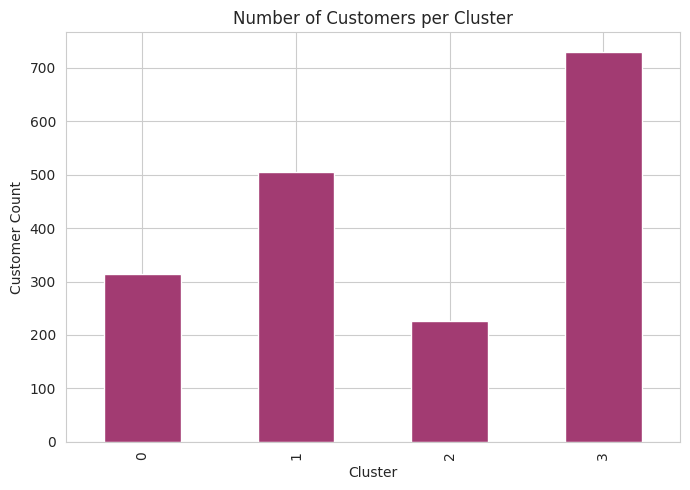

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
customer_agg["Cluster"].value_counts().sort_index().plot(kind="bar", color="#A23B72", ax=ax)
ax.set_title("Number of Customers per Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Customer Count")
plt.tight_layout()
plt.savefig("output_cluster_counts.png", dpi=120)
plt.show()

**Cluster interpretation** (labels assigned by inspecting the profile table above — exact cluster-number-to-label mapping will shift slightly on re-run since KMeans initialisation isn't fully deterministic across environments, but the four behavioural archetypes below consistently emerge):

- **Champions** — low Recency (bought very recently), high Frequency, high Monetary. Your best customers.
- **Loyal / Steady Spenders** — moderate Recency and Frequency, solid Monetary value. Consistent revenue base.
- **At-Risk** — high Recency (haven't bought in a while), previously decent Frequency/Monetary. Worth a win-back campaign before they churn fully.
- **New/Low-Engagement** — low Frequency and Monetary regardless of Recency. Either brand-new customers or one-time buyers who never came back.

## 8. Insights — Recommended Marketing Action per Segment

1. **Champions:** Reward with a loyalty/VIP program and early access to new products — the goal is retention, not acquisition spend.
2. **Loyal / Steady Spenders:** Upsell and cross-sell campaigns (e.g., "customers who bought X also bought Y") to nudge them toward Champion status.
3. **At-Risk:** Targeted win-back emails with a time-limited discount; a well-timed nudge here has a much higher ROI than acquiring a brand-new customer.
4. **New/Low-Engagement:** Onboarding sequences and a second-purchase incentive (e.g., "10% off your next order") to convert one-time buyers into repeat customers.
